# RSM338 Assignment 5
## March 25, 2026
### Ethan Wang, Kevin Yang

## 1. Data Preparation

In [57]:
# Load in the data
import pandas as pd

df = pd.read_excel('lending_clubFull_Data_Set.xlsx')
df

,Unnamed: 0,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,...,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,0,263591,545710,20000.0,60 months,17.93,342.94,E,E5,Wylie ISD,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,1,1613916,69664096,30000.0,36 months,11.99,996.29,C,C1,Sergeant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
2,2,818934,8965180,21500.0,36 months,11.99,714.01,B,B3,Designer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
3,3,1606612,70572960,10000.0,36 months,13.67,340.18,C,C3,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
4,4,1639932,68589517,5000.0,36 months,8.49,157.82,B,B1,Sr. Manufacturing Engineer,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24995,901888,4974773,10500.0,36 months,10.16,339.60,B,B1,Schneider Electric,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24996,24996,945413,1279809,12000.0,36 months,14.33,412.06,C,C1,Clark County School District,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24997,24997,366944,63496281,25000.0,36 months,12.69,838.63,C,C2,sales consultant,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
24998,24998,1043529,98124387,12200.0,60 months,13.49,280.66,C,C2,NaN,...,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN


Now that we loaded the data, we must  choose useful features for our analysis. As stated, many of the columns are redundant, so we should try to make our dataset more managable before our analysis.

### 1.1 Defining the Target Variable
We need a binary outcome for the loans - default or not - but we are given several outcomes. Let's first see all the unique loan outcomes.

In [58]:
# Display all unique values in the 'loan_status' column
unique_loan_status = df['loan_status'].unique()
unique_loan_status

array(['Charged Off', 'Current', 'Fully Paid', 'Late (31-120 days)',
       'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off', 'Default',
       nan], dtype=object)

After some brief research, we decided to define the following loan outcomes as default:

**['Charged Off', 'Late (31-120 days)', 'Does not meet the credit policy. Status:Charged Off']**

We believe that these are either explicitly defaulted, or highly likely to be defaulted. The rest of the outcomes are either paid off, being paid on time, or still recoverable. Going forward in our code, default loans will be represented using a dummy equal to 1.

### 1.2 Selecting Features
The features we have decided to select are:

[*'delinq_2yrs', 'annual_inc', 'num_accts_ever_120_pd', 'pct_tl_nvr_dlq', 'dti', 'loan_amnt', 'home_ownership', 'emp_length'*]

These features can be grouped as follows:

**Past Behaviour**

*'delinq_2yrs' (delinquencies in the last 2 years)* and *'pct_tl_nvr_dlq' (percent of trades never delinquent)* tell us about the borrower's previous behaviour. Having one or more delinquencies in the past, especially relatively recent ones, signal higher credit risk. It tells us that the borrower may have questionable self-judgement on their ability to repay debts.

**Repaying Power**

*'annual_inc' (annual income)* and *'dti'(monthly debt-to-income ratio)* tells us about the earning power of the borrower. Even if a borrower has unfortunate circumstances that may affect their payments, if they have a strong basis for their ability to repay, then it is very possible for the debt to be recovered over time.

**Stability**

*'home_ownership' (ownership status i.e., rent, mortgage)* and *'emp_length' (in years, 0-10)* tell us if the borrower has a stable life. Borrowers with stability in their lives will have much more predictable repayments compared to one who is constantly moving and/or job-hopping.

**Loan Risk**

*'loan_amnt' (the amount applied for by borrower)* tells us about the borrower's perceived debt capacity. If a borrower has external signals that suggest credit risk, but they perceive the repayments to be feasible, it may suggest the borrower has an appetite for risk, which is unattractive to lendors. It also tells us the overall burden of the loan on the borrower, not just if they can make payments in the short-term.

### 1.3 Handling Missing Values and Data Types 

In [59]:
# 1. Handle missing values (Example: dropping rows with any NAs in selected features)
features_to_use = ['delinq_2yrs', 'annual_inc', 'num_accts_ever_120_pd', 'pct_tl_nvr_dlq', 'dti', 'loan_amnt', 'home_ownership', 'emp_length', 'loan_status']
df_cleaned = df[features_to_use].dropna()
df_cleaned.head()

,delinq_2yrs,annual_inc,num_accts_ever_120_pd,pct_tl_nvr_dlq,dti,loan_amnt,home_ownership,emp_length,loan_status
1,3.0,136000.0,1.0,90.0,20.63,30000.0,MORTGAGE,10+ years,Current
2,0.0,50000.0,0.0,100.0,29.62,21500.0,RENT,1 year,Fully Paid
4,0.0,88000.0,1.0,60.0,5.32,5000.0,MORTGAGE,10+ years,Current
5,0.0,38500.0,0.0,100.0,33.73,16150.0,RENT,10+ years,Charged Off
6,0.0,40000.0,0.0,100.0,19.11,18400.0,RENT,8 years,Current


Theoretically, no applicant should have missing values in any of the columns. Missing values here, like income, would be highly problematic, as it should just be 0, not NaN. Therefore, we feel comfortable dropping all missing values from the data.

In [60]:
# Display all unique values in the 'home_ownership' column
unique_home_status = df['home_ownership'].unique()
unique_home_status

array(['MORTGAGE', 'RENT', 'OWN', 'ANY', 'OTHER', 'NONE', nan],
      dtype=object)

In [61]:
# Selecting categorical columns
categorical_cols = ['home_ownership']

# Perform One-Hot Encoding
# drop_first=True to avoid the "Dummy Variable Trap" 
df_cleaned = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

df_cleaned.head()

,delinq_2yrs,annual_inc,num_accts_ever_120_pd,pct_tl_nvr_dlq,dti,loan_amnt,emp_length,loan_status,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT
1,3.0,136000.0,1.0,90.0,20.63,30000.0,10+ years,Current,True,False,False,False,False
2,0.0,50000.0,0.0,100.0,29.62,21500.0,1 year,Fully Paid,False,False,False,False,True
4,0.0,88000.0,1.0,60.0,5.32,5000.0,10+ years,Current,True,False,False,False,False
5,0.0,38500.0,0.0,100.0,33.73,16150.0,10+ years,Charged Off,False,False,False,False,True
6,0.0,40000.0,0.0,100.0,19.11,18400.0,8 years,Current,False,False,False,False,True


We decided to encode home ownership status to have dummies for each status. While it would have been possible to assign a number to each status, we felt that it would hurt the interpretability of the variable, as there is no clear ranking for types of ownership. Many applicants would be unfairly hurt by a ranking of ownership, as renting versus owning have different trade-offs for individuals that may not be income related. Therefore, we feel it is unfair to rank the ownership, and multiple dummies would provide better interpretability and predictive power.

In [62]:
# Create the mapping dictionary based on the dataset categories
emp_map = {
    '< 1 year': 0, 
    '1 year': 1, 
    '2 years': 2, 
    '3 years': 3, 
    '4 years': 4,
    '5 years': 5, 
    '6 years': 6, 
    '7 years': 7, 
    '8 years': 8, 
    '9 years': 9, 
    '10+ years': 10
}

# Apply it to the 'emp_length' column
df_cleaned['emp_length'] = df_cleaned['emp_length'].map(emp_map)

# Check the result - it should now be 0.0 to 10.0
print(df_cleaned['emp_length'].value_counts())

emp_length
10    8127
2     2140
3     1889
0     1833
1     1525
4     1432
5     1403
6     1146
8     1042
7     1032
9      960
Name: count, dtype: int64


For employment length, we decided to map the data type to integers. We chose to assign '< 1 year' to 0, and '10+ years' to 10. We believe that this is the most logical ranking for employment length, as it keeps the integer values in the original dataset, while providing intuitive values for the non-integer values.

In [63]:
# Define which categories count as Default (1)
# Everything else will be Repaid (0)
default_categories = [
    'Charged Off', 
    'Default', 
    'Late (31-120 days)', 
    'Does not meet the credit policy. Status:Charged Off'
]

# Create the binary target column
df_cleaned['default'] = df_cleaned['loan_status'].apply(lambda x: 1 if x in default_categories else 0)
df_cleaned.drop('loan_status', axis=1, inplace=True)
df_cleaned.head()

,delinq_2yrs,annual_inc,num_accts_ever_120_pd,pct_tl_nvr_dlq,dti,loan_amnt,emp_length,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,default
1,3.0,136000.0,1.0,90.0,20.63,30000.0,10,True,False,False,False,False,0
2,0.0,50000.0,0.0,100.0,29.62,21500.0,1,False,False,False,False,True,0
4,0.0,88000.0,1.0,60.0,5.32,5000.0,10,True,False,False,False,False,0
5,0.0,38500.0,0.0,100.0,33.73,16150.0,10,False,False,False,False,True,1
6,0.0,40000.0,0.0,100.0,19.11,18400.0,8,False,False,False,False,True,0


In [64]:
# Report the final dimensions of the cleaned dataset
print(f"Final dimensions after cleaning and encoding: {df_cleaned.shape}")

Final dimensions after cleaning and encoding: (22529, 13)


The final dimensions of our dataset are $22,529 \times 13$. It should be noted we had to drop the 'ANY' home ownership column to avoid the dummy variable trap. We also dropped the 'loan_status' now that it has been encoded as a dummy variable.

### 1.4 Splitting Training and Test Data, and Standardization

In [65]:
# Splitting the train/test sets
from sklearn.model_selection import train_test_split
X = df_cleaned.drop('default', axis=1)
y = df_cleaned['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

In [66]:
# Standarizing the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit and transform the training data
# This calculates the mean/std of the training set and scales it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data
# CRITICAL: We only use the mean/std from the training set here
X_test_scaled = scaler.transform(X_test)

The data has now been split $80/20$ for training and testing respectively, and standardized so it can be used for analysis.

## 2. Baseline Classifiers
Let's fit the four classifiers - logistic regression, linear discriminant analysis, K-nearest neighbours, and a decision tree.

In [67]:
# Logistic Regression

import time

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, random_state=23)

# 1. Start the clock
start_log = time.time()

# 2. Fit the model to training data
log_reg.fit(X_train_scaled, y_train)

# 3. Stop the clock
end_log = time.time()

# 4. Calculate the difference
log_reg_time = end_log - start_log

# print(f"Logistic Regression Training Time: {log_reg_time:.4f} seconds")

In [68]:
# Linear Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()

# 2. Record the start time
start_lda = time.time()

# 3. Fit the model to training data
lda_model.fit(X_train_scaled, y_train)

# 4. Record the end time and calculate duration
end_lda = time.time()
lda_time = end_lda - start_lda

# print(f"LDA Training Time: {lda_time:.4f} seconds")

In [69]:
# K Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the values of K to test
param_grid = {'n_neighbors': [3, 5, 7, 10, 12, 15, 20]}

# 2. Initialize KNN
knn = KNeighborsClassifier()

# 3. Setup GridSearchCV with 10 folds
# We use 'accuracy' as the scoring metric to decide the "best" K
grid_search = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')

# 4. Time the process
start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
cv_time = time.time() - start_time

# 5. Results
print(f"Best K selected: {grid_search.best_params_['n_neighbors']}")
print(f"Total CV Training Time: {cv_time:.4f} seconds")

Best K selected: 20
Total CV Training Time: 11.6701 seconds


To justify the use of 10-fold cross-validation for both the KNN and Decision Tree models, we selected this approach to ensure our performance was statistically stable and not influenced by lucky data splits. By training on 90% of the data across ten distinct iterations, we felt that we minimized the bias of our model while giving it exposure to diverse borrower profiles. We felt that 10-folds would be robust against the inherent risks of KNN being sensitive to noise and Decision Trees being prone to overfitting. Ultimately, this ensures that the selected hyperparameters, such as $K=20$ and a maximum depth of 5, are reliable choices for predicting loan defaults across the entire dataset.

In [70]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# 1. Initialize the model
dt_model = DecisionTreeClassifier(max_depth=5, random_state=23)

# 2. Record the start time for the ENTIRE CV process
start_dt_cv = time.time()

# 3. Perform 10-fold Cross-Validation
# This fits the model 10 different times on different "folds"
cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=10)

# 4. Record the end time
dt_cv_time = time.time() - start_dt_cv

#print(f"Decision Tree 10-Fold CV Mean Accuracy: {cv_scores.mean():.4f}")
#print(f"Total CV Training Time: {dt_cv_time:.4f} seconds")

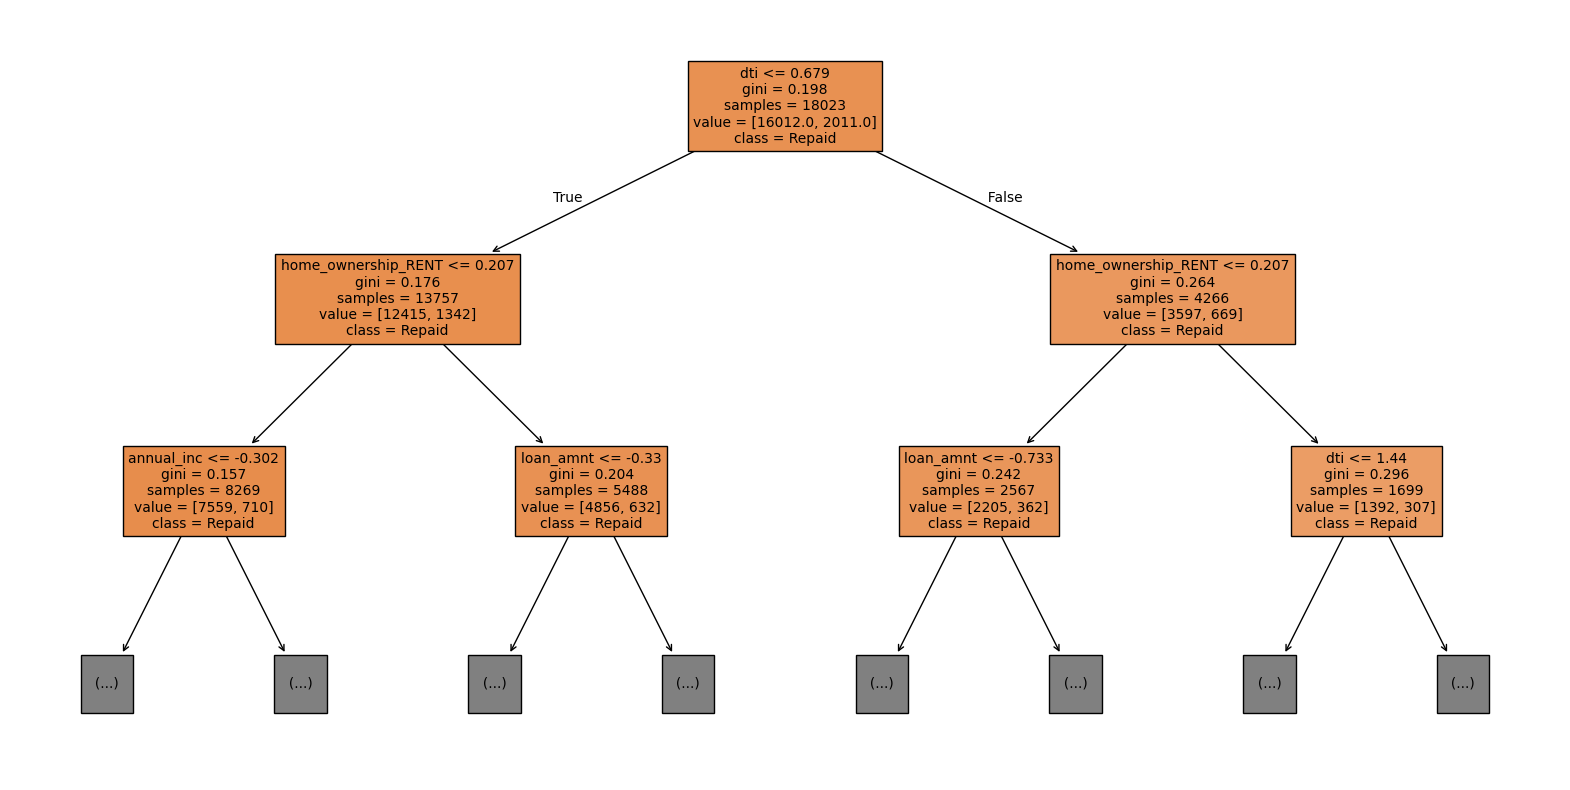

In [71]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_model.fit(X_train_scaled, y_train)

plt.figure(figsize=(20,10))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=['Repaid', 'Default'], 
          filled=True,
          fontsize=10,
          max_depth=2) # We only show the top of the tree so it's readable
plt.show()

The decision tree identifies debt-to-income (dti) as the most critical factor for predicting loan outcomes, as it serves as the root split. It creates an hierarchy of risk, where borrowers with lower debt and stable housing (non-renters) are consistently filtered into the highest-probability "Repaid" class.

### 2.1 Model Accuracy and Time 

In [72]:
# Creating the data dictionary
# Replace 'log_reg_accuracy', 'log_reg_time', etc., with your actual variable names
results_data = {
    'Model': ['Logistic Regression', 'LDA', 'K-Nearest Neighbors', 'Decision Tree'],
    'Test Accuracy': [
        log_reg.score(X_test_scaled, y_test),
        lda_model.score(X_test_scaled, y_test),
        grid_search.score(X_test_scaled, y_test), # This uses your best K=20
        dt_model.score(X_test_scaled, y_test)
    ],
    'Training Time (s)': [
        log_reg_time, 
        lda_time, 
        cv_time, # Total time for the 10-fold CV search
        dt_cv_time
    ]
}

# Creating the DataFrame
df_results = pd.DataFrame(results_data)

# Displaying the table
df_results

,Model,Test Accuracy,Training Time (s)
0,Logistic Regression,0.885708,0.014366
1,LDA,0.885708,0.019501
2,K-Nearest Neighbors,0.886152,11.670113
3,Decision Tree,0.885264,0.214613


A notable finding is the consistency in testing accuracy across all four models, with each hovering around 88.5%. This suggests that the predictive power is likely limited by the features selected rather than the specific model used. For a creditor, this accuracy-ceiling indicates that moving to more complex models may not necessarily better identify high-risk borrowers without incorporating additional features into the model.

While the accuracy of all the models is similar, the efficiency may indicate which model is best for our dataset and objectives.

The logisitic regression and linear discriminant analysis models are the most efficient, training in a fraction of a second. This makes them ideal for high-volume environments where thousands of loan applications must be processed in real-time, given that the features are not too complex and do not require as much flexibility.

The decision tree was also a strong choice of model for this dataset. While slightly slower than the other models, it was highly efficient and offers the added benefit of interpretability, because we can see where the tree decides to split.

The training time for KNN is significantly higher at nearly 30 seconds. This is because the model selection process involved 10-fold cross-validation to optimize $K$. Since we had a list of 7 possible values of $K$, it runs 10 folds for 7 times, resulting in this long training time. While the training time for the optimal $K$ is likely similar to the other models, we felt that trying to optimize $K$ is a material burden that any lending institution would be subject to when using KNN, so we decided to include it.

### 2.2 Confusion Matrices

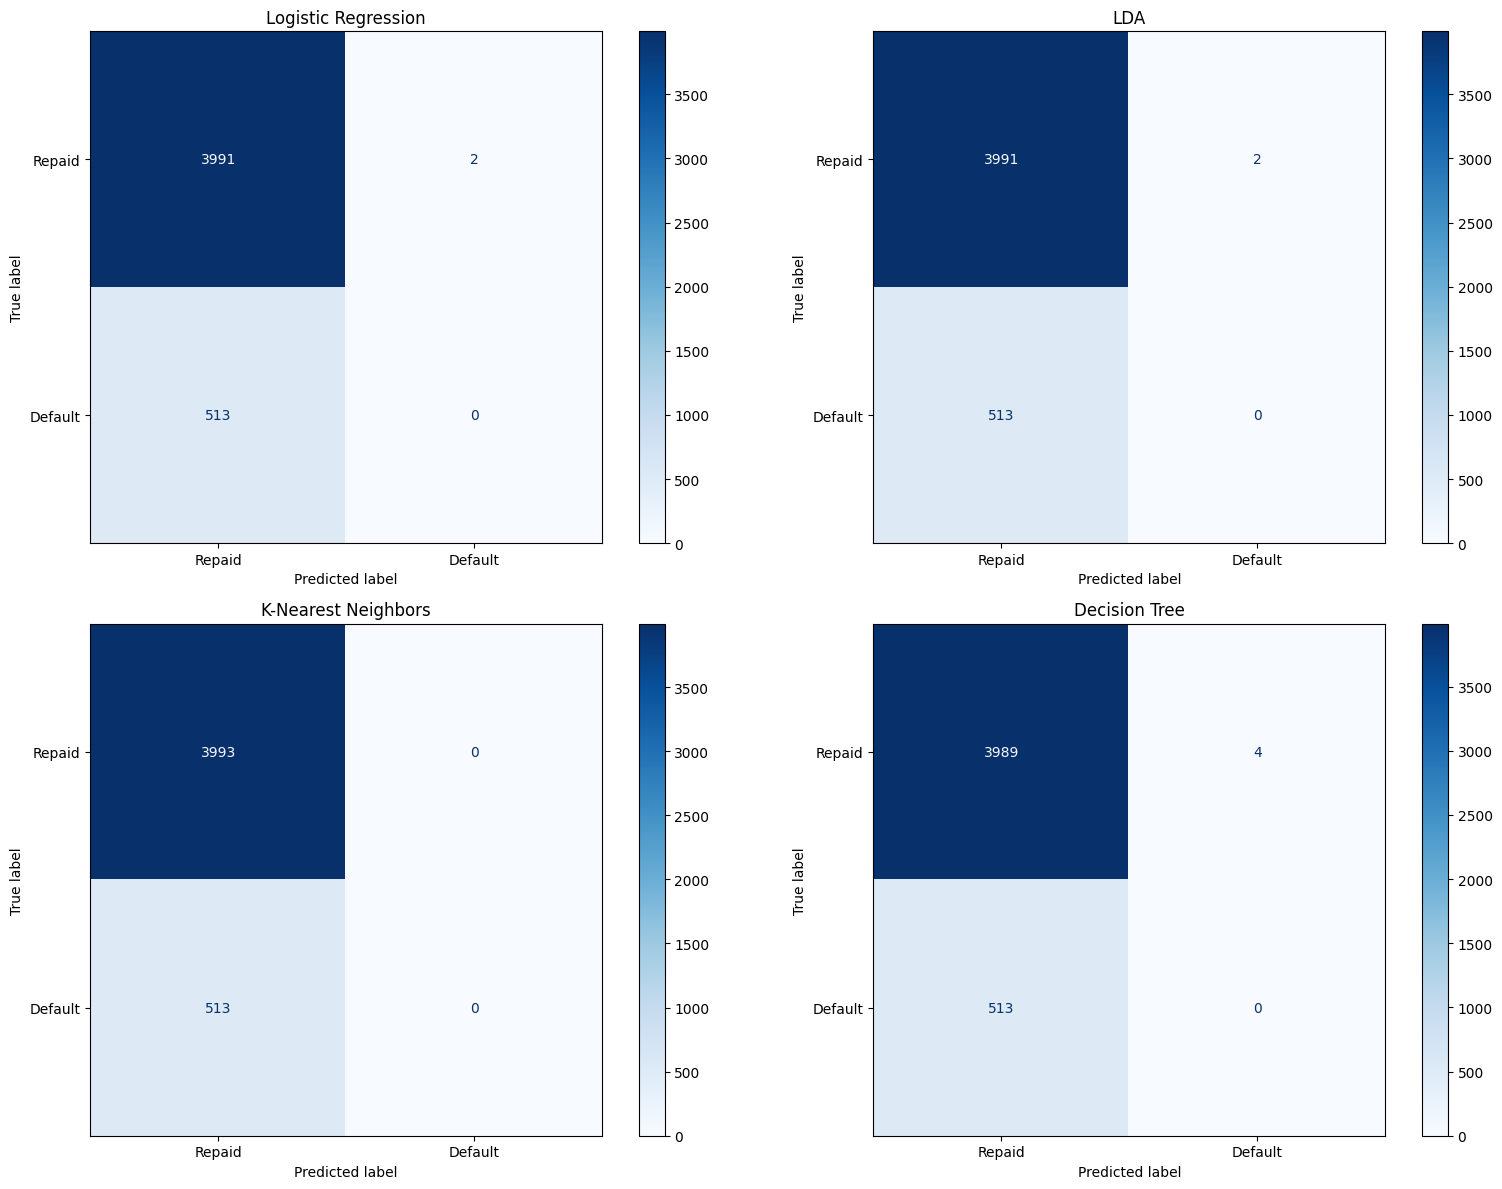

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Group your models into a list
# Update 'lda_model' or 'grid_search' if your variable names are different
models = [
    ('Logistic Regression', log_reg),
    ('LDA', lda_model),
    ('K-Nearest Neighbors', grid_search), 
    ('Decision Tree', dt_model)
]

# 2. Set up a 2x2 grid for the plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Flattens the 2x2 grid into a simple list of 4 so we can loop through it

# 3. Loop through each model, predict, and plot
for i, (name, model) in enumerate(models):
    # Predict on the test set
    predictions = model.predict(X_test_scaled)
    
    # Calculate the matrix
    cm = confusion_matrix(y_test, predictions)
    
    # Plot it on the specific axis
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Repaid', 'Default'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'{name}')

# 4. Clean up the layout and display
plt.tight_layout()
plt.show()

In this context, the false positives are borrowers who were incorrectly identified as defaulters (Type I), and the false negatives are borrowers who were misclassed as acceptable (Type 2). From the lender's perspective, a false negative would be far costlier, especially if it was a loan with a lower interest rate, as now the borrower is unable to repay the loan and there is no high interest payment to compensate for the true, unseen credit risk.

Despite a high headline accuracy of ~88%, every model failed to correctly identify a single defaulting borrower (0 True Positives in all four bottom-right quadrants). This indicates that the classifiers are effectively defaulting to a prediction that every borrower will repay, which makes them basically useless for credit risk evaluation.

While KNN could technically be labeled the "best" among these options because it had no false positives, this is a hollow achievement. The 513 false negatives (Type II error) represent a 100% failure rate in detecting high-risk borrowers, which is the most critical part, much like the other models.

### 2.3 Evaluation Metrics
Accuracy is an insufficient metric for this dataset because the high 'Repaid' baseline allows a useless model to appear successful while failing to identify a single actual default.

From a lender's perspective, recall for the default class is the most critical metric.
Recall measures what percentage of actual defaulters the model successfully caught, which all our models have been struggling with.
In our current results, our models' recall for defaults is 0%.
A lender's primary risk is the loss of the loan principal. While precision is nice, recall is what prevents bankruptcy. We would rather a model be slightly too strict by flagging some good borrowers for review than a model that allows 513 people to default.
We have also incorporated the F1-Score to provide a balanced measure of the models' ability to mitigate risk without unnecessarily restricting loan volume. 
Finally, we add ROC-AUC, or Area Under the Receiver Operating Characteristic Curve. This metric is good for imbalanced datasets such as ours, as it evaluates across all thresholds. Therefore, it is quite useful for our case in comparing different models. A higher ROC-AUC close to 1 is better.



In [74]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# 1. Generate predictions
log_preds = log_reg.predict(X_test_scaled)
lda_preds = lda_model.predict(X_test_scaled)
knn_preds = grid_search.predict(X_test_scaled)
dt_preds = dt_model.predict(X_test_scaled)

# 2. Generate predicted probabilities (needed for ROC-AUC)
log_probs = log_reg.predict_proba(X_test_scaled)[:,1]
lda_probs = lda_model.predict_proba(X_test_scaled)[:,1]
knn_probs = grid_search.predict_proba(X_test_scaled)[:,1]
dt_probs = dt_model.predict_proba(X_test_scaled)[:,1]

# 3. Compile the metrics into a dictionary
results_data_v2 = {
    'Model': ['Logistic Regression', 'LDA', 'K-Nearest Neighbors', 'Decision Tree'],

    'Test Accuracy': [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, lda_preds),
        accuracy_score(y_test, knn_preds),
        accuracy_score(y_test, dt_preds)
    ],

    'Recall (Defaults)': [
        recall_score(y_test, log_preds),
        recall_score(y_test, lda_preds),
        recall_score(y_test, knn_preds),
        recall_score(y_test, dt_preds)
    ],

    'F1-Score': [
        f1_score(y_test, log_preds),
        f1_score(y_test, lda_preds),
        f1_score(y_test, knn_preds),
        f1_score(y_test, dt_preds)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, lda_probs),
        roc_auc_score(y_test, knn_probs),
        roc_auc_score(y_test, dt_probs)
    ]
}

# 4. Create and display the DataFrame
df_results_v2 = pd.DataFrame(results_data_v2)
df_results_v2.round(3)

,Model,Test Accuracy,Recall (Defaults),F1-Score,ROC-AUC
0,Logistic Regression,0.886,0.0,0.0,0.613
1,LDA,0.886,0.0,0.0,0.611
2,K-Nearest Neighbors,0.886,0.0,0.0,0.551
3,Decision Tree,0.885,0.0,0.0,0.584


A recall of zeroes across the board occurs because the algorithms default to a 50% classification threshold. Given the class imbalance, where the vast majority of loans are repaid, the models are never more than 50% confident that a default will occur, leading them to blindly accept every applicant.

## 3 Ensemble Methods

For this section, we will fit three ensemble classifiers on the same training data. First, a Random Forest, then an ADABoost, and finally an XGBoost.

As we learned in lecture 8, the reason we use ensemble models is to combat the high variance in decision trees. By combining many trees into an ensemble, we try to make the team of models stronger than an individual tree or model.

### 3.1 Random Forest
#### 3.1.1 Model Fitting

A random forest algorithm uses bagging combined with feature subsampling. This means it first draws a bootstrap sample, then grows a tree. At each split in the tree, it randomly selects features and finds the best split among those features, and repeats for each tree. The prediction is done by majority vote.

In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import time

param_grid_rf = {
    'n_estimators': [1000], # Tested from 100-1000 with 100, 500, 1000
    'max_depth': [10], # Tested 10, 20, 30, None
    'min_samples_leaf': [10],  # Tested 1, 5, 10
    'max_features': ['sqrt'] # Tested 'sqrt' and 'log2'
}

In [76]:
rf = RandomForestClassifier(
    oob_score=True,
    random_state=23,
    n_jobs=-1
)
start_rf = time.time()

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

end_rf = time.time()
rf_time = end_rf - start_rf

best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)


Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 1000}


In [77]:
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:,1]

In [78]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)
rf_cm = confusion_matrix(y_test, y_pred_rf)

print("Accuracy:", rf_accuracy)
print("AUC:", rf_auc)
print("Confusion Matrix:\n", rf_cm)
print("Training Time:", rf_time)

Accuracy: 0.8861517976031957
AUC: 0.6047864464567378
Confusion Matrix:
 [[3993    0]
 [ 513    0]]
Training Time: 17.620661973953247


The hyperparameters we tuned for the random forest were number of estimators, max features, max depth, and minimum observations in a leaf.

For number of estimators in a random forest, the greater number of trees the better, and the only limitation is computation time. We set the limit at 1000 to search through to keep computation time efficient. Therefore, the cross-validation chose a higher number of trees of 1000 according to a typical range of 100-1000 trees.

For max features, we typically use sqrt for classification as default, but we also inclueded log2 just to check and make sure. Unsuprisingly, sqrt was the one that was chosen. This means that we use square root of p as the max number of features out of p avaliable features.

For minimum observations, a typical range is 1-10. We decided to choose values in this typical range to search. Our cross validation choose 10 as the best choice out of 1, 5, and 10. We end up using 10. Overall, hyperparameters are less important in the Random Forest model, as performance is less sensitive to the hyperparameter choices we make.

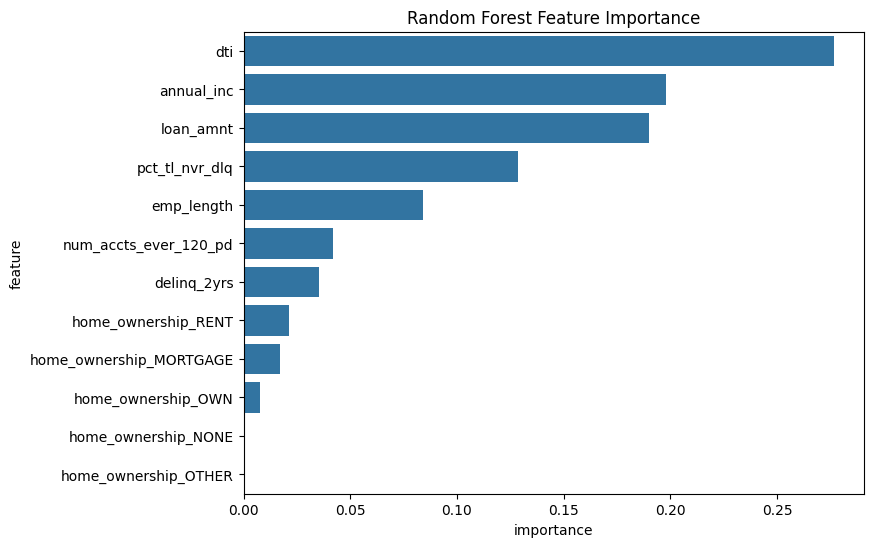

In [79]:
import seaborn as sns
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_rf.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance, x="importance", y="feature")
plt.title("Random Forest Feature Importance")
plt.show()

The random forest predicts debt to income ratio, annual income, and loan amount as the three most important features. This aligns with my common intuition that income is a key factor impacting loan default. The debt to income ratio makes a lot of sense,  as a borrower with more debt obligations could struggle to make loan payments.

#### 3.1.2 Random Forest Out-of-Bag (OOB) performance

In [80]:
print("OOB Score:", best_rf.oob_score_)
print("Accuracy:", rf_accuracy)

OOB Score: 0.8884203517727348
Accuracy: 0.8861517976031957


 We fit the Random Forest with OOB as True to get the OOB out of sample estimate. This fits the forest once instead of multiple times to give a estimate of out-of-sample performance, which is a more efficient method to do so. 

 The model got an OOB score of 0.888 and a test accuracy of 0.886. These values are very close to each other, which shows that the OOB estimate provides a reliable approximation of the model’s out-of-sample performance. This suggests that the model generalizes well and there are no signs of overfitting the training data.

### 3.2 AdaBoost

AdaBoost is the first practical boosting algorithm, and the way it works is by having a set of weights over the training observations. It is also known as Adaptive Boosting. Each round of training, the weights are adjusted. Misclassified observations' weights are increased, or boosted, so that in the next round the classifier can try harder on those observations. This is a sequential model, which means that each tree depends on the previous. The benefits of AdaBoost are that it reduces bias, however there is a higher risk of overfitting if there are too many rounds.

In [81]:
from sklearn.ensemble import AdaBoostClassifier
base_tree = DecisionTreeClassifier(max_depth=1, random_state=23)
param_grid_ada = {
    "n_estimators": [600], # Tested 50, 100, 200, 300, 400, 600, 800, 1000
    "learning_rate": [0.8] # Tested 0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0
}
#Best Parameters: {'learning_rate': 0.8, 'n_estimators': 600}

In [82]:
ada = AdaBoostClassifier(
    estimator=base_tree,
    random_state=23
)
start_ada = time.time()

ada_grid = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

ada_grid.fit(X_train_scaled, y_train)

end_ada = time.time()
ada_time = end_ada - start_ada
best_ada = ada_grid.best_estimator_

print("Best Parameters:", ada_grid.best_params_)

Best Parameters: {'learning_rate': 0.8, 'n_estimators': 600}


In [83]:
y_pred_ada = best_ada.predict(X_test_scaled)
y_prob_ada = best_ada.predict_proba(X_test_scaled)[:,1]

ada_accuracy = accuracy_score(y_test, y_pred_ada)
ada_auc = roc_auc_score(y_test, y_prob_ada)
ada_cm = confusion_matrix(y_test, y_pred_ada)

print("Accuracy:", ada_accuracy)
print("AUC:", ada_auc)
print("Confusion Matrix:\n", ada_cm)
print("Training Time:", ada_time)

Accuracy: 0.8861517976031957
AUC: 0.6125273321880542
Confusion Matrix:
 [[3993    0]
 [ 513    0]]
Training Time: 10.885488986968994


The hyperparameters we tuned for the AdaBoost were number of rounds, and learning rate. In general, a smaller learning rate and more trees/rounds would beat a large learning rate and few trees. We used a 5 fold cross validation on ROC-AUC to select combinations of number of rounds and learning rate.

For number of rounds in an AdaBoost, we searched values from 50 to 1000. This was a reasonable range that also was computationally feasible. The CV chose 600 rounds.

For learning rate, we decided to search values from 0.1, 0.2, 0.3, 0.4, 0.5, 0.8, and 1. This includes a wide range of rates so that we can get a suitable number. The CV chose a relatively larger learning rate of 0.8.

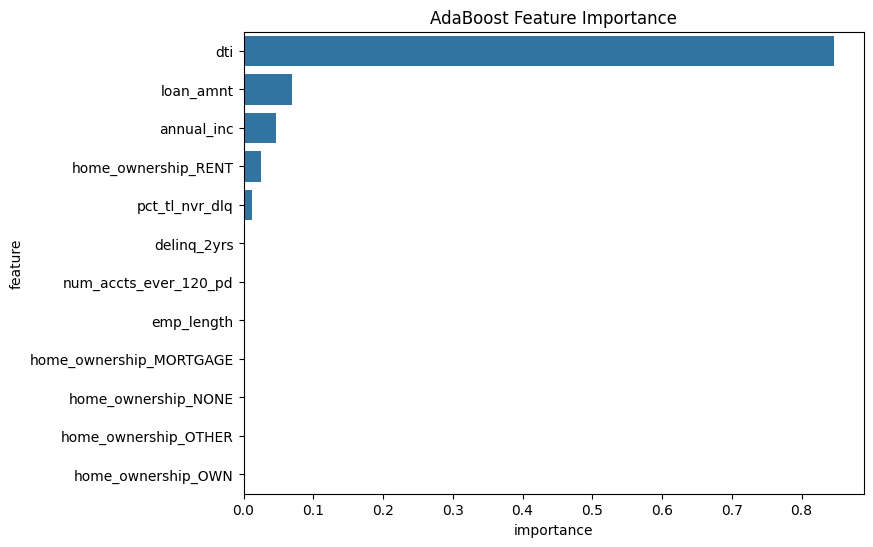

In [84]:
feature_importance_ada = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_ada.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance_ada, x="importance", y="feature")
plt.title("AdaBoost Feature Importance")
plt.show()

Similar to the Random Forest model, the ADABoost predicts that Debt to Income ratio is the most important feature impacting loan default. As mentioned earlier, this makes a lot of intuitive sense as debt to income takes into account both the size of your income and how your debt compares to your income. However, it is strange to see that other features such as home ownership status, or income on its own have such little importance.

### 3.3 XGBoost

XGBoost stands for extreme gradient boosting. It adds a regularization penalty which applies to trees that are too complicated or predict extreme values. This balances prediction accuracy and model complexity. It is strong for financial data that includes many observations and features with both numeric and categorical variables.

In [85]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    random_state=23,
    eval_metric="logloss",
    use_label_encoder=False
)
param_grid_xgb = {
    "n_estimators": [100], #Tested from 100-1000 with 100 increments
    "max_depth": [3], # Tested 3, 5, 8
    "learning_rate": [0.05] # Tested 0.01, 0.05, 0.10, 0.25, 0.1, 0.2, 0.3
}
# Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

In [86]:
start_xgb = time.time()

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

end_xgb = time.time()
xgb_time = end_xgb - start_xgb

best_xgb = xgb_grid.best_estimator_

print("Best Parameters:", xgb_grid.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


/Users/ethan/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [06:12:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ethan/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [06:12:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ethan/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [06:12:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/ethan/anaconda3/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [06:12:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



In [87]:
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

print("Accuracy:", xgb_accuracy)
print("AUC:", xgb_auc)
print("Confusion Matrix:\n", xgb_cm)
print("Training Time:", xgb_time)

Accuracy: 0.8861517976031957
AUC: 0.6136215960777364
Confusion Matrix:
 [[3993    0]
 [ 513    0]]
Training Time: 0.21924424171447754


The hyperparameters we tuned for the XGBoost were number of rounds(estimators), tree depth, and learning rate. For other parameters, we used the default values. For example, we used the default L2 regularization of 1.0. We selected these hyperparameters to tune because they have the most important impact on model performance, and preventing overfitting.

For number of rounds in an XGBoost, we searched values from 100 to 1000, using 100 round intervals. This was a typical range that included multiple options, and not overly computational draining. The CV chose 100 rounds.

For learning rate, we decided to search values from 0.01, 0.05, 0.10, 0.25, 0.1, 0.2, 0.3. This includes a good variety of learning rates from the typical range of 0.01 to 0.3. The CV chose a learning rate of 0.05.

For max depth, we chose from 3, 5, and 8, within the typical range of 3 to 8. The CV chose 3.

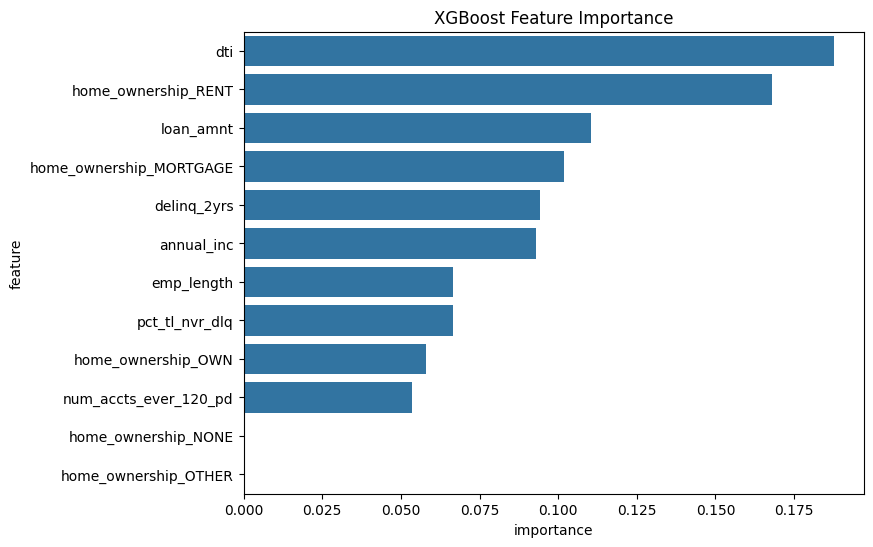

In [88]:
feature_importance_xgb = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_xgb.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feature_importance_xgb, x="importance", y="feature")
plt.title("XGBoost Feature Importance")
plt.show()

From XGBoost's feature importance, again Debt to Income ratio remains in the top spot. However, home ownership status becomes much more important. For instance, rent status is almost as high as dti, at around 0.17, and mortgage status is around 0.1. This makes intuitive sense, as mortgage payers tend to carry higher debt due to their mortgage. However, it is also suprising as I would also think that people who have bought houses and taken out mortgages have better financial situations.

### 3.4 Model Evaluation
We evaluate our models based on accuracy, recall, and F1, and compare with the previous models from part 2.

In [89]:
# Generate predictions
rf_preds = best_rf.predict(X_test_scaled)
ada_preds = best_ada.predict(X_test_scaled)
xgb_preds = best_xgb.predict(X_test_scaled)

# Generate predicted probabilities for ROC-AUC
rf_probs = best_rf.predict_proba(X_test_scaled)[:,1]
ada_probs = best_ada.predict_proba(X_test_scaled)[:,1]
xgb_probs = best_xgb.predict_proba(X_test_scaled)[:,1]

# Create dataframe for ensemble models
ensemble_results = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost', 'XGBoost'],

    'Test Accuracy': [
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, ada_preds),
        accuracy_score(y_test, xgb_preds)
    ],

    'Recall (Defaults)': [
        recall_score(y_test, rf_preds),
        recall_score(y_test, ada_preds),
        recall_score(y_test, xgb_preds)
    ],

    'F1-Score': [
        f1_score(y_test, rf_preds),
        f1_score(y_test, ada_preds),
        f1_score(y_test, xgb_preds)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, ada_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

# Append to previous results
df_results_v2 = pd.concat([df_results_v2, ensemble_results], ignore_index=True)

# Display updated results
df_results_v2.round(3)

,Model,Test Accuracy,Recall (Defaults),F1-Score,ROC-AUC
0,Logistic Regression,0.886,0.0,0.0,0.613
1,LDA,0.886,0.0,0.0,0.611
2,K-Nearest Neighbors,0.886,0.0,0.0,0.551
3,Decision Tree,0.885,0.0,0.0,0.584
4,Random Forest,0.886,0.0,0.0,0.605
5,AdaBoost,0.886,0.0,0.0,0.613
6,XGBoost,0.886,0.0,0.0,0.549


**Do the ensemble methods improve over the baseline classifiers from Problem 2? By how much? Is the improvement large enough to justify the added model complexity?**

From the table, we see that test accuracy remained the same across all models, due to the fact that our models did not predict any defaults. This is shown as recall and F1 score are all 0. Therefore, we focus on the ROC-AUC.

From the ROC-AUC, we see that the logistic regression and LDA performed well among the baseline classifiers. The ensemble methods were not able to see a significant improvement, with only the AdaBoost coming close at 0.613, matching the best baseline classifier of logistic regression. The Random Forest and XGBoost all performed worse than the best baseline classifiers. 

Because there was no significant improvement made, we believe that there is not enough to justify the added model complexity at this point. The ensemble methods require more tuning, computational time, and interpretation. Furthermore, there is less risk of potential overfitting or any technical issues that could arise from a more technical model. For a business, implementation is also important, and you want to use the cheapest option avaliable. Large models could use a lot of resources, talent, and take a very long time to set up.

The lending platform faces the tradeoff between potential increased predictive power and complexity. In our case the increased predictive power is minimal, so the added model complexity is not justified.


## 4 Model Selection and Deployment
### 4.1 ROC Curve and AUC

c:\Users\kevin\Python Projects\RSM338\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [06:10:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


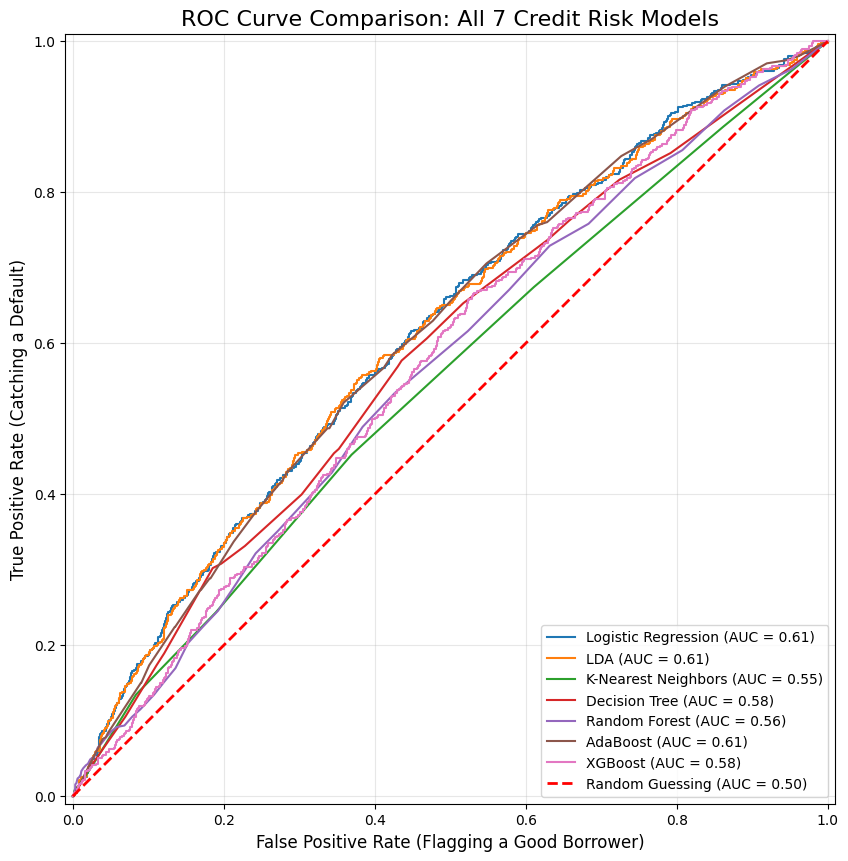

In [ ]:
from sklearn.metrics import RocCurveDisplay

rf.fit(X_train_scaled, y_train)
ada.fit(X_train_scaled, y_train)
xgb.fit(X_train_scaled, y_train)

# 1. Group all 7 models. 
# Check that the variable names on the right match your notebook exactly!
models = [
    ('Logistic Regression', log_reg),
    ('LDA', lda_model),
    ('K-Nearest Neighbors', grid_search), 
    ('Decision Tree', dt_model),
    ('Random Forest', rf),
    ('AdaBoost', ada),
    ('XGBoost', xgb)
]

# 2. Set up a large figure so the 7 lines don't get too cramped
fig, ax = plt.subplots(figsize=(12, 10))

# 3. Loop through your list and plot each curve automatically
for name, model in models:
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name=name)

# 4. Add the "Random Guessing" baseline
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Random Guessing (AUC = 0.50)')

# 5. Clean up the formatting for the report
plt.title('ROC Curve Comparison: All 7 Credit Risk Models', fontsize=16)
plt.xlabel('False Positive Rate (Flagging a Good Borrower)', fontsize=12)
plt.ylabel('True Positive Rate (Catching a Default)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

There are three models tied for the best, albeit lackluster, area under the curve (AUC) of 0.61. Those three models are Logistic Regression, Linear Discriminatory Analysis, and AdaBoost. This is slightly surprising, as the first two are relatively simple models, yet they outperformed the other models on the test data.

The ranking is consistent given the models' evaluation metrics in the summary table. The summary table showed that all models achieved near-identical accuracies (~88.5%), but simultaneously had a Recall of 0.0, meaning they failed to identify any actual defaults. The identical accuracy was reflecting the dataset's "Repaid" class imbalance at the default 0.5 threshold. The AUC metric bypassed this threshold issue to reveal the true predictive power of the classifiers, showing that Logistic Regression, LDA, and AdaBoost were superior at ranking underlying credit risk compared to the other models.

That being said, we believe using Logistic Regression is the best choice in these circumstances. This is because it is the simplest and does not assume our data follows the standard distribution. It provides equal predictive power and interpretability without needind bell-shaped data. This interpretability is especially important because  legally, it would be very difficult to justify denying a loan because a black-box model like AdaBoost decided to.

For those reasons, we decided that Logistic Regression would be most suitable.

### 4.2 Cost of Defaulting and Thresholds

In [ ]:
# 1. FIXED: Get the raw probabilities for the 'Default' class (index 1)
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1] 

# 2. Define the thresholds from the prompt
thresholds = [0.3, 0.4, 0.5, 0.6]
results = []

# 3. Loop through and calculate the cost for each
for thresh in thresholds:
    # Create custom predictions: 1 if probability >= threshold, else 0
    custom_preds = (y_probs >= thresh).astype(int) 
    
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, custom_preds).ravel()
    
    # Calculate the Total Cost using the 5:1 ratio
    total_cost = (fp * 1) + (fn * 5)
    
    results.append({
        'Threshold': thresh,
        'False Positives (Cost=1)': fp,
        'False Negatives (Cost=5)': fn,
        'Total Penalty Cost': total_cost
    })

# 4. Display the results
cost_df = pd.DataFrame(results)
cost_df

,Threshold,False Positives (Cost=1),False Negatives (Cost=5),Total Penalty Cost
0,0.3,3,513,2568
1,0.4,2,513,2567
2,0.5,2,513,2567
3,0.6,2,513,2567


Mathematically, the thresholds of 0.4, 0.5, and 0.6 best minimize the total penalty cost to 2,567. Dropping the threshold to 0.3 actually increased the total cost by 1 because it introduced an additional false positive without successfully catching any new defaults.

However, from a lending institution's perspective, the results show that all of these thresholds are still too high. Because the false negatives remained at 513 across the thresholds, it indicates the model never assigned a default probability higher than 30% to any borrower. To put the 5:1 cost penalty into practice and force the model to start identifying risky loans, we would need to lower the classification threshold significantly. This would likely be closer to the baseline default rate of the entire portfolio (e.g., 10%-15%).

### 4.3 Memo to the Risk Team

To: Risk Team Manager  
Memo on Model Selection

After evaluating several classification models for predicting borrower default, we recommend deploying a Logistic Regression model with a lowered classification threshold.  

Across the seven models tested of Logistic Regression, LDA, K-Nearest Neighbors, Decision Tree, Random Forest, AdaBoost, and XGBoost—overall test accuracy was very similar (around 88.6%). However, accuracy was not a useful measure in this problem because the dataset is highly imbalanced, with far fewer defaults than non-defaults. At the standard 0.5 threshold, every model predicted borrowers as non-default, which produced high accuracy but failed to identify any actual defaults. Evidence of this was found in our model metrics table, where recall was 0 across the board.  

To better compare model performance, we evaluated ROC-AUC, which measures how well each model distinguishes between defaulting and non-defaulting borrowers across all possible thresholds. Logistic Regression and AdaBoost achieved the highest ROC-AUC values of around 0.613, indicating the strongest ability to rank risky borrowers ahead of safer ones. More complex ensemble models such as Random Forest and XGBoost did not show a meaningful improvement over these simpler models.
  
From the lending platform we then found that the business cost of approving a borrower who later defaults is estimated to be five times larger than rejecting a borrower who would repay. Therefore, the classification threshold should be lowered below 0.5 to increase detection of risky borrowers. Adjusting the threshold allows the model to identify more potential defaults while still maintaining reasonable overall performance. Right now, the models are not predicting defaults, so the threshold lowering is a very crucial and necessary step.

We recommend Logistic Regression because it matches the predictive performance of the three ensemble models while remaining far simpler and more interpretable. Its coefficients clearly show how borrower characteristics influence default risk, which is valuable for transparency, regulatory communications, and internal strategy and decision making. As a baseline model, we believe that it can also help save your team valuable resources such as time and technical talent, and be implemented and deployed quicker to be used in real situations, while not sacrificing any performance.

Based on these results, I recommend deploying Logistic Regression with a reduced decision threshold to better detect potential defaults while maintaining an interpretable and efficient model.

# 5 Note on GenAI Usage

Generative AI was used to complete this project. Specifically, OpenAI's GPT 5.2 was used to complete coding tasks. The process we used was to ask the tool to complete code on a certain part of the question. For example, a prompt would be "help me parse the date column to convert it to datetime format". For markdown, AI was only used to generate mathematical formulas. **AI was not used to generate blocks of markdown or write explanations. All the additional writing and explanations was done by ourselves in our own words.**
  
Overall, AI assistance was helpful for this lab report. It helped to solve issues we had working with Git, as well as debugging when things went wrong. For example, in this assignment it helped us understand more clearly the process of tuning the ensemble models.